# Two-layer dynamic neural field

This notebook demonstrates a two-layer field architecture using `FieldSystem`: a planning field coupled to a memory field that accumulates above-threshold activation traces. For a three-layer architecture (planning + memory + perception), see `examples/shadowing.ipynb`.

In [1]:
from pyphonplan import FieldSystem
from pyphonplan.viz import plot_field_heatmap

## 2-layer field: planning + memory

A planning field receives external input and forms peaks via lateral interactions (local excitation, surround inhibition). A memory field slowly accumulates above-threshold activation from the planning field, providing a persistent trace after the planning peak subsides.

### Create the field system

Initialize a `FieldSystem` spanning [-10, 10]. Note that we intialize with `FieldSystem` rather than `DynamicField` because we're coupling a system of fields, rather than a single field. The kernel parameters control the shape of lateral interactions: `c_exc`/`sigma_exc` set excitatory strength and width, `c_inh`/`sigma_inh` set inhibitory strength and width, and `c_global` adds global inhibition across the field's range.

We first add a planning field, which has its own kernel.

In [2]:
sys = FieldSystem(x_min=-10, x_max=10, step_size=0.02)

# planning field with kernel params
kernel_params = dict(c_exc=4, c_inh=1, c_global=0.5, sigma_exc=1.0, sigma_inh=2.0, expand=3.0)
sys.add_field("planning", tau=25, h=-2, kernel_params=kernel_params)

### Add memory field

Memory fields (`field_type="memory"`) differ from standard fields: they accumulate above-threshold activation from a designated `source_field` and decay slowly (`tau_decay=500`). The resting level `h` is ignored for memory fields (always initialized at 0). Coupling weights control how strongly the memory field feeds back into the planning field. In this case, we couple the memory field to the planning field with `weight=2`.

In [3]:
kernel_memory = dict(c_exc=4, c_inh=1, c_global=0.0, sigma_exc=1.0, sigma_inh=2.0, expand=3.0)
sys.add_field(
    "memory", tau=150, h=0, kernel_params=kernel_memory,
    field_type="memory", tau_decay=500, source_field="planning"
)

# memory -> planning coupling
sys.add_coupling("memory", "planning", weight=2.0)

## Add inputs

We add two Gaussian inputs to the field at spatial locations `-5` and `+5`. Both inputs have the same amplitude, but the amplitudes can vary if needed. `input1` is active between time steps [50, 150], while `input2` is active between [100, 200]. Let's assume for now that these values represent milliseconds and they are integer values. Assuming integer values in the dynamic field simplifies some later analyses, such as identifying peak activations over time.

Note that we name the field the inputs are added to `planning` and then name the input for future reference (e.g. `input1`). The subsequent code plots the kernel, sigmoid and inputs.

In [4]:
sys.add_input("planning", "input1",amplitude=10, position=-5, width=1.0, start=50, end=150)
sys.add_input("planning", "input2",amplitude=10, position=5, width=1.0, start=100, end=200)

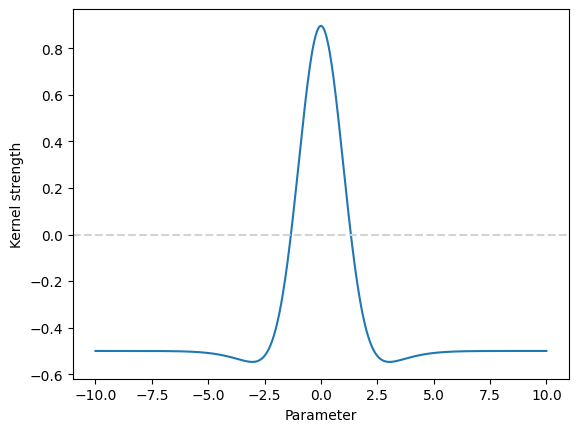

In [5]:
sys.plot_kernel("planning");

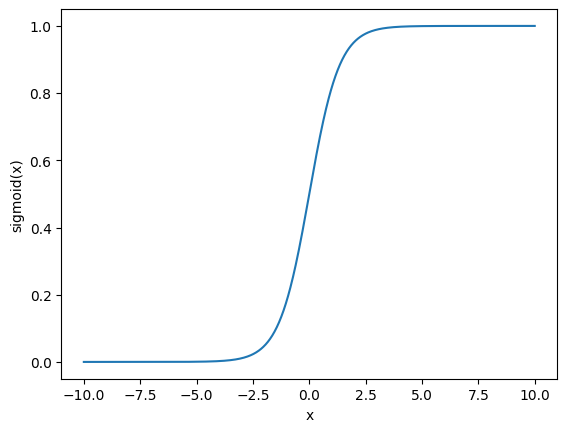

In [6]:
sys.plot_sigmoid("planning");

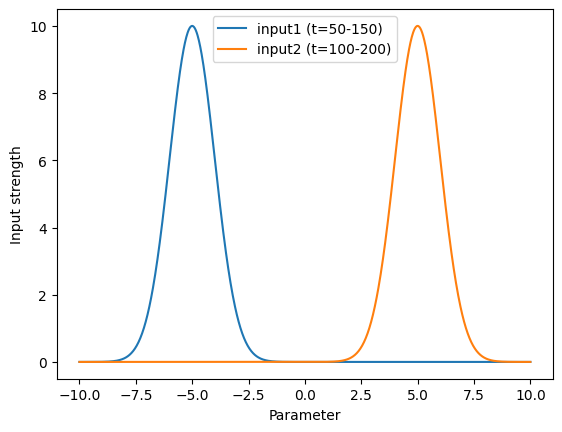

In [7]:
sys.plot_inputs("planning");

### Solve and visualize

We now solve the coupled system of fields. We see the two inputs in the planning field, with peak activation switching abruptly between the input peaks. The memory field stores a trace history of above-threshold activation dynamics, which may bias subsequent productions and/or allow memory representations to change over time.

In [8]:
sys.solve(t_start=0, t_end=250)

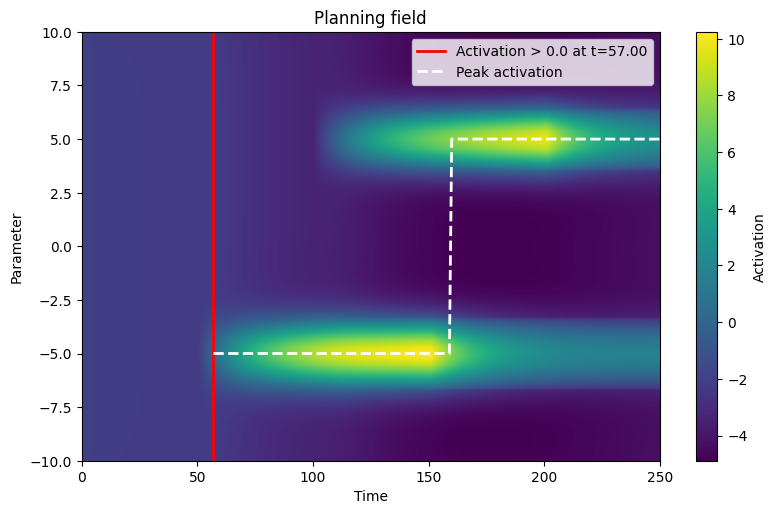

In [9]:
plot_field_heatmap(sys.time, sys.x, sys.activation["planning"], title="Planning field");

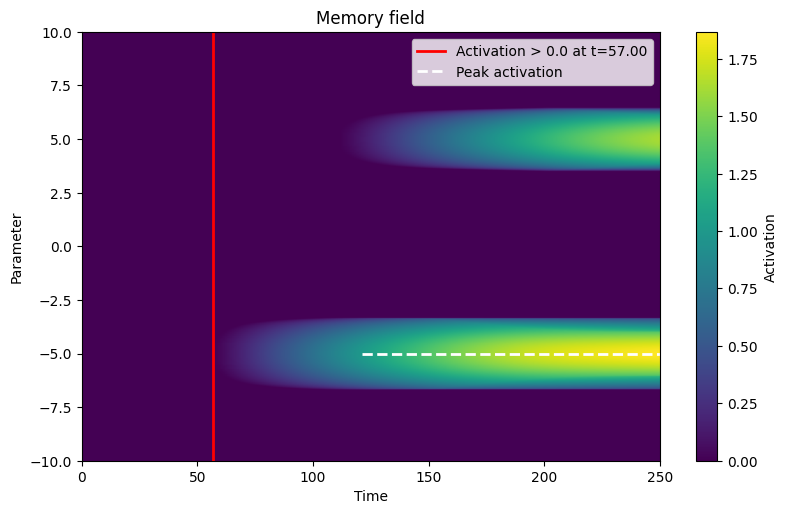

In [10]:
plot_field_heatmap(sys.time, sys.x, sys.activation["memory"], title="Memory field");